# 053 — Signal evolution per model

User selected models signals comparison over the images in `data/test/`.  
Signals are compared accordingly to the model's family. 

Imports and a GPU sanity check.


In [ ]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.calibration import laplace_sigma_from_scale, learned_zscore, structural_zscore
from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import analyze_delta
from scripts.trainer import load_model
from scripts.trainer_nll import load_model_nll
from scripts.visualization_nll import plot_signal_gallery

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Every test image

Every `(rgb, ir)` pair under `data/test/`.


In [3]:
TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR = project_root / "data" / "test" / "ir"

rgb_paths = sorted(TEST_RGB_DIR.glob("*.jpg")) if TEST_RGB_DIR.exists() else []
rgb_paths += sorted(TEST_RGB_DIR.glob("*.png")) if TEST_RGB_DIR.exists() else []
image_pairs = [
    (p, TEST_IR_DIR / p.name)
    for p in sorted(rgb_paths)
    if (TEST_IR_DIR / p.name).exists()
]

print(f"data/test/ images: {len(image_pairs)} | {[p.stem for p, _ in image_pairs]}")

if not image_pairs:
    raise RuntimeError("No (rgb, ir) pairs found under data/test/.")

data/test/ images: 10 | ['GT01', 'GT02', 'GT03', 'bridge', 'case', 'face', 'green', 'modern', 'modern2', 'total']


## 2. Choose which models to sweep

Each entry is `(architecture, family, loss)`:
- `architecture` is the model name used across the project  
- `family` is `"deterministic"` or `"nll"`  
- `loss` is `"laplace_nll"` for every heteroscedastic architecture. 



In [4]:
MODELS = [
    # ---- deterministic ----
    #("unet", "deterministic", None),
    #("unet_residual", "deterministic", None),
    #("resunet", "deterministic", None),
    #("attention_unet", "deterministic", None),
    #("efficientnet_unet", "deterministic", None),
    #("efficientnet_unet_ft", "deterministic", None),
    #("unet_v2", "deterministic", None),
    #("unet_restormer", "deterministic", None),
    #("unet_dilated", "deterministic", None),
    #("unet_v2_dilated", "deterministic", None),
    # ---- heteroscedastic (NLL) ----
    #("unet_nll", "nll", "laplace_nll"),
    ("resunet_nll", "nll", "laplace_nll"),
    ("attention_unet_nll", "nll", "laplace_nll"),
    #("efficientnet_unet_nll", "nll", "laplace_nll"),
    #("efficientnet_unet_nll_ft", "nll", "laplace_nll"),
]
BETA = settings.NLL_BETA


def display_name(arch: str, family: str, loss: str | None) -> str:
    # Every NLL entry is "laplace_nll" now (fixing.md #10); no more
    # gaussian/beta variant suffix needed, so this is just the arch name.
    return arch


models: dict = {}
model_family: dict[str, str] = {}

for arch, family, loss in MODELS:
    name = display_name(arch, family, loss)
    try:
        if family == "deterministic":
            models[name] = load_model(
                arch, model_dir=settings.MODELS_DIR / "deterministic"
            )
        else:
            models[name] = load_model_nll(
                arch, model_dir=settings.MODELS_DIR / "nll", loss_name=loss, beta=BETA
            )
    except FileNotFoundError as exc:
        print(f"[skip] {exc}")
        continue
    model_family[name] = family

print(f"Sweeping: {list(models)}")
if not models:
    raise RuntimeError("None of the models in MODELS have a checkpoint on disk.")


2026-09-05 17:51:16.262879: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-09-05 17:51:16.262914: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-09-05 17:51:16.262918: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-09-05 17:51:16.263102: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-05 17:51:16.263111: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Sweeping: ['resunet_nll', 'attention_unet_nll']


## 3. Build signals

In [5]:
def load_pair(rgb_path: Path, ir_path: Path) -> tuple[np.ndarray, np.ndarray]:
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0
    return rgb, ir


def signals_for_model(
    name: str, rgb: np.ndarray, ir: np.ndarray
) -> dict[str, np.ndarray]:
    """Every signal this one model produces, keyed by signal-type label.

    Deterministic models get raw delta / structural delta (they have no
    sigma to normalize by). Heteroscedastic models get only the
    sigma-normalized signals (|z|, structural z) instead — normalizing is
    the whole point of predicting sigma, so the un-normalized pair is
    dropped here rather than shown alongside its own refinement.
    """
    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    h, w = ir.shape
    batch = padded[tf.newaxis, ...]

    pred = models[name].predict(batch, verbose=0)[0, :h, :w, :]
    is_nll = model_family[name] == "nll"
    mu = pred[..., 0]
    result = analyze_delta(ir, mu)

    if is_nll:
        # Every NLL architecture trains as Laplace since fixing.md #10's
        # Round 2 collapse, so laplace_sigma_from_scale applies uniformly.
        sigma = laplace_sigma_from_scale(np.exp(pred[..., 1]))
        return {
            "|z| (raw/sigma)": learned_zscore(ir, mu, sigma),
            "structural z": structural_zscore(result.structural_delta, sigma),
        }
    return {
        "raw delta": result.raw_delta,
        "structural delta": result.structural_delta,
    }

## 4. Per-model signal evolution, every image

One figure per model per image:  
- real IR
- every signal that model produces (according to model's family), each on its own scale.   




=== GT01 ===


2026-09-05 17:51:17.764412: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


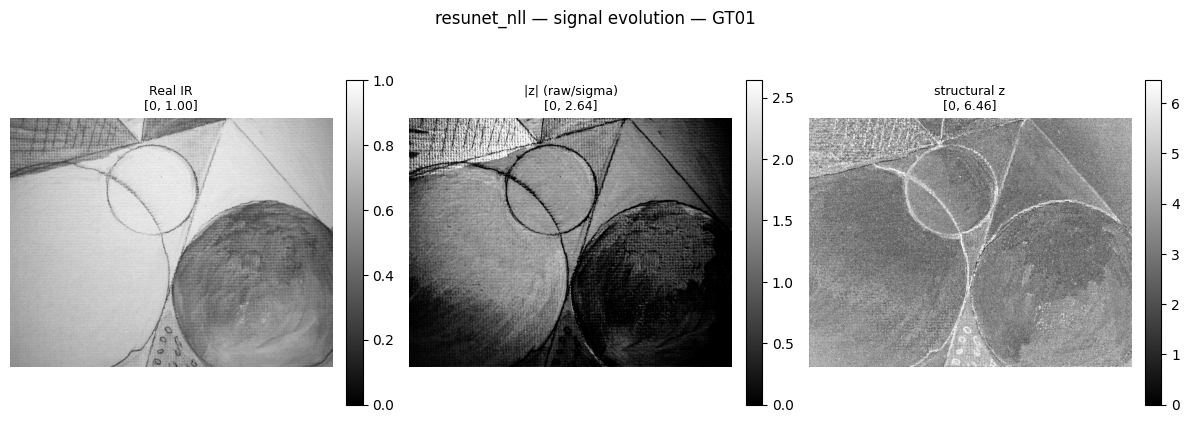

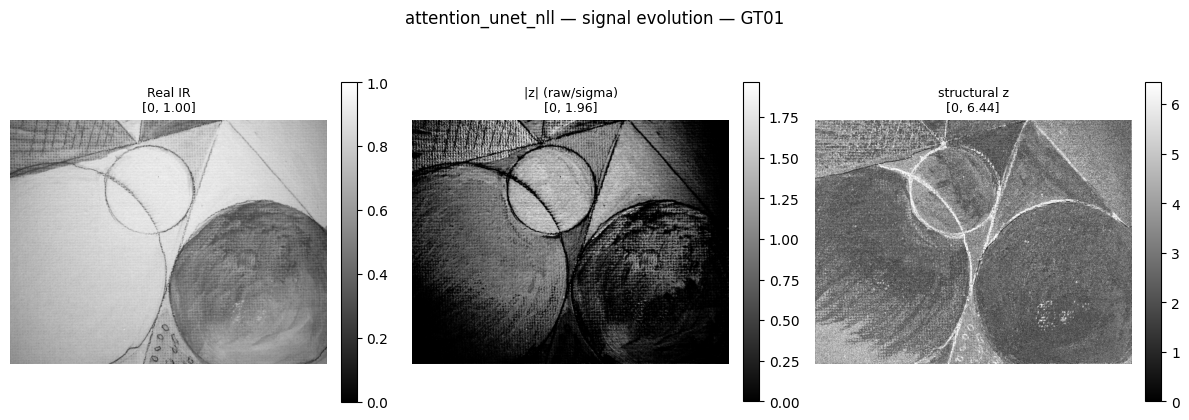


=== GT02 ===


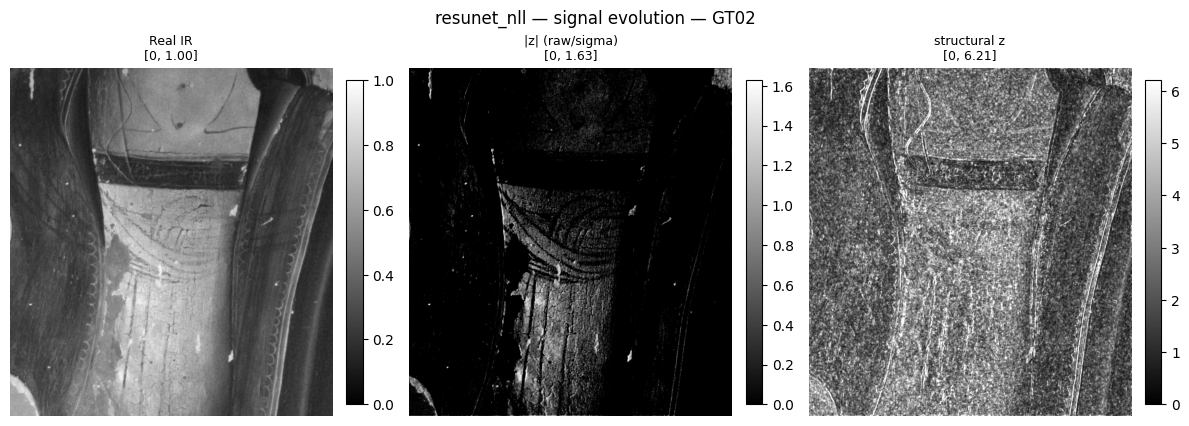

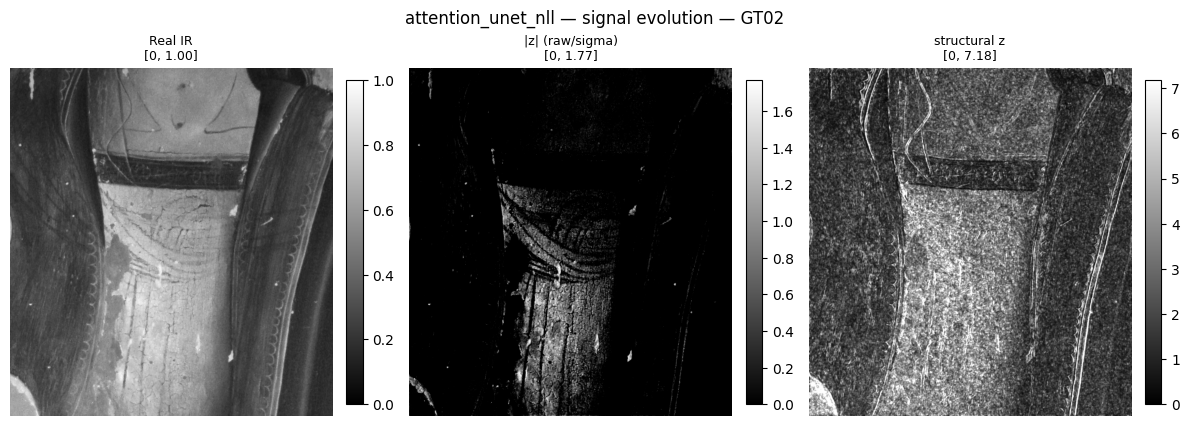


=== GT03 ===


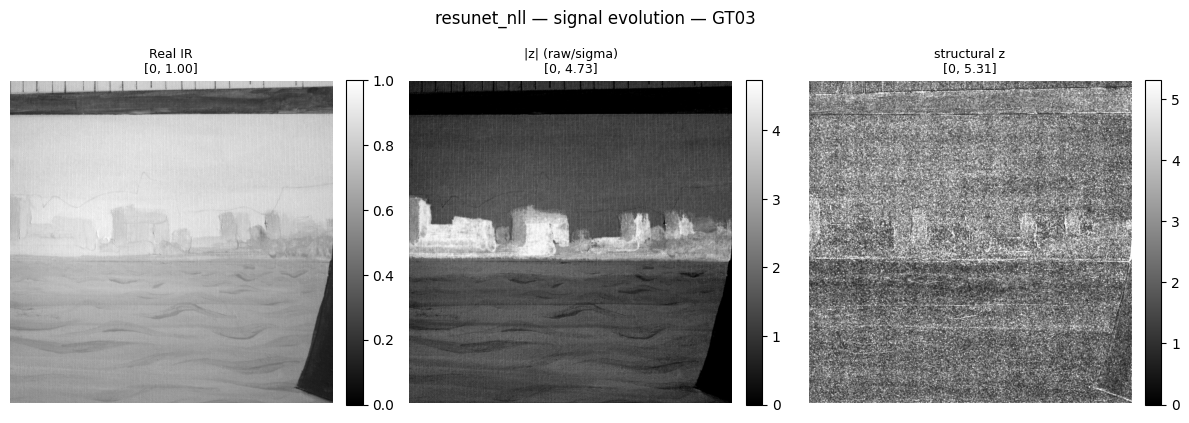

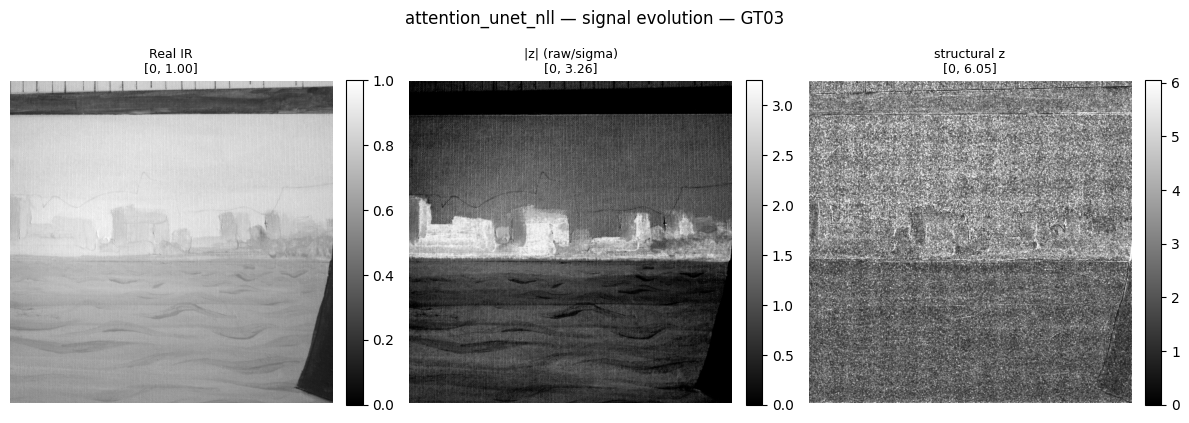


=== bridge ===


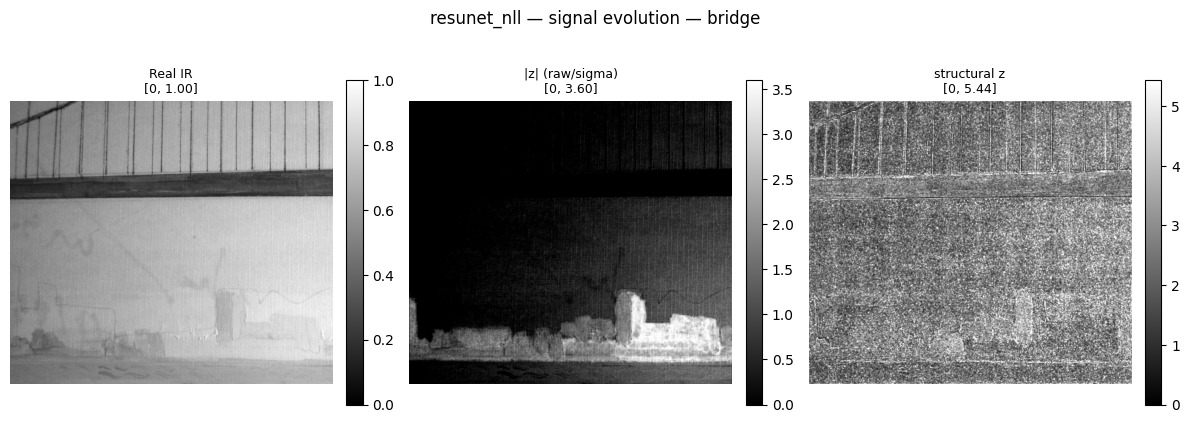

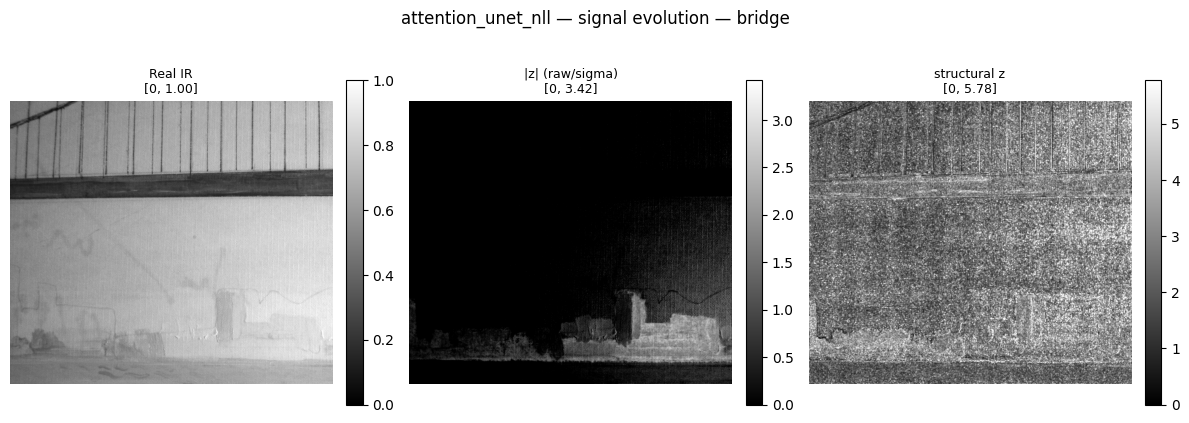


=== case ===


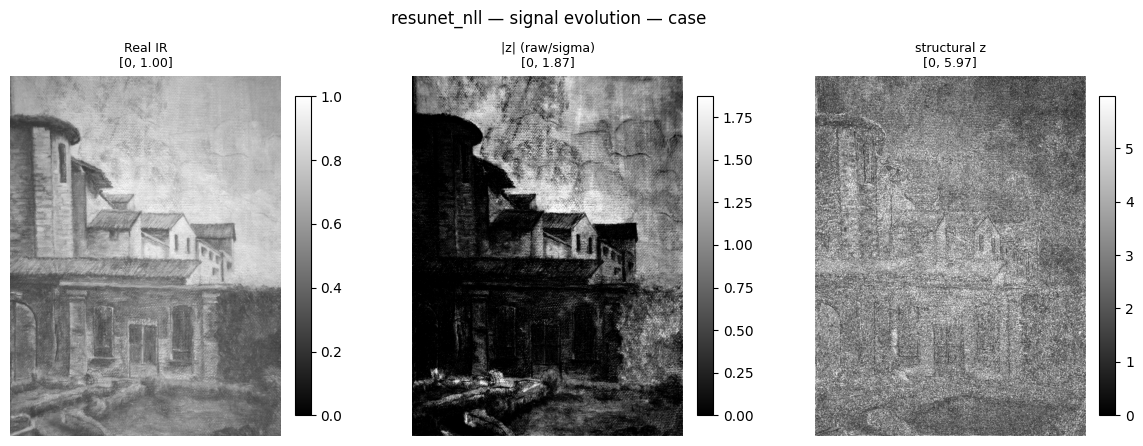

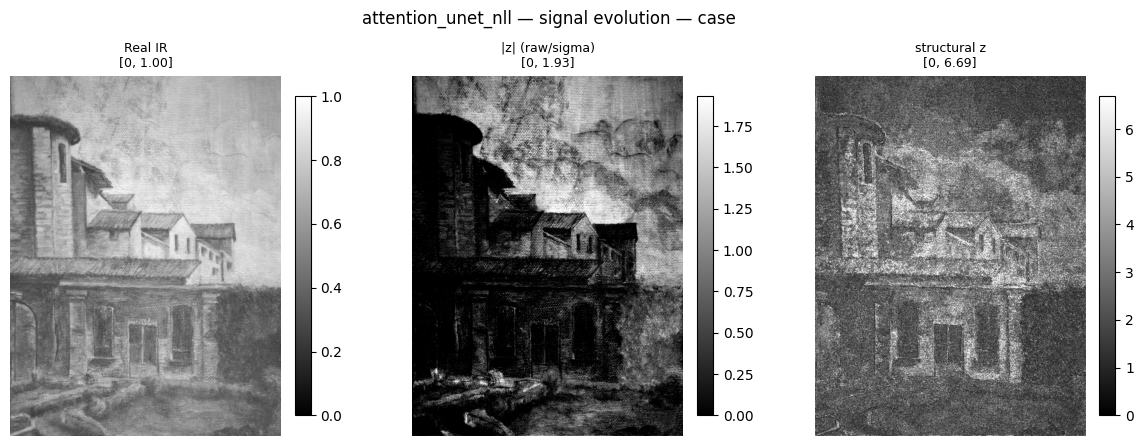


=== face ===


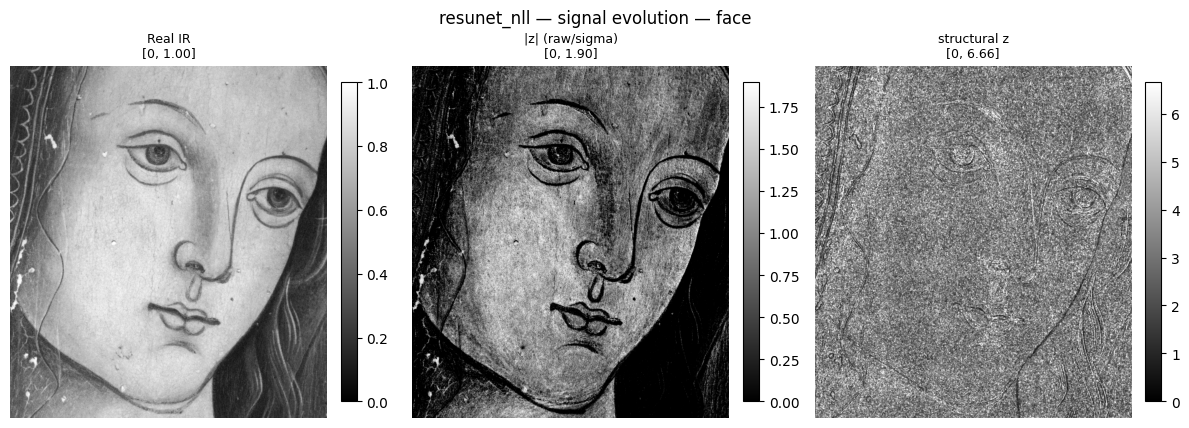

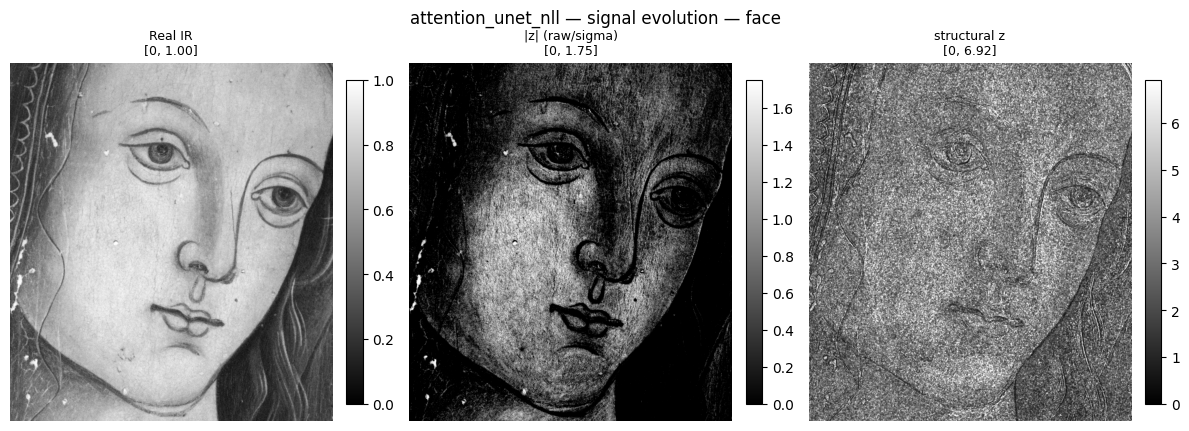


=== green ===


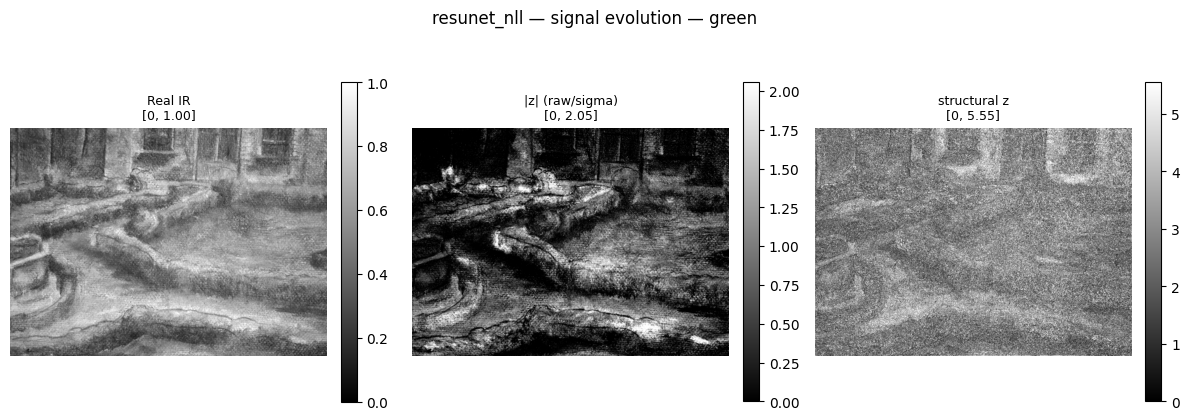

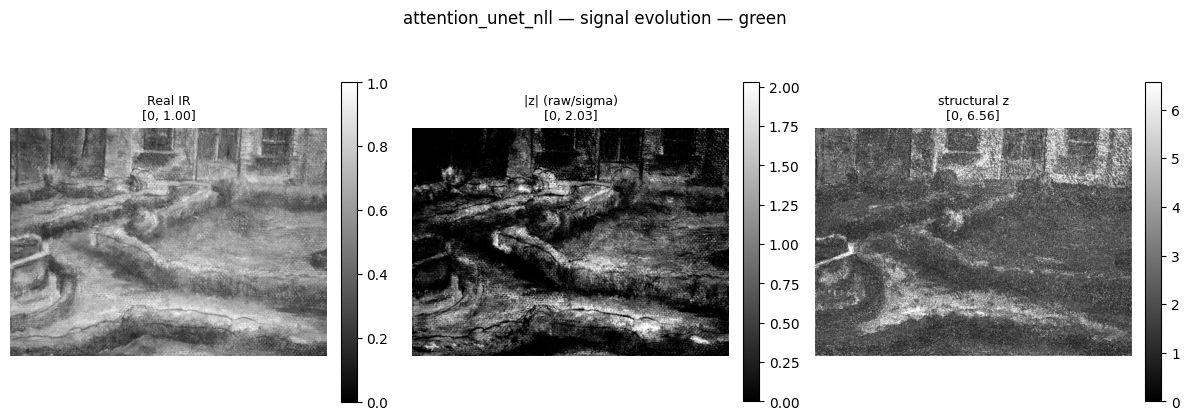


=== modern ===


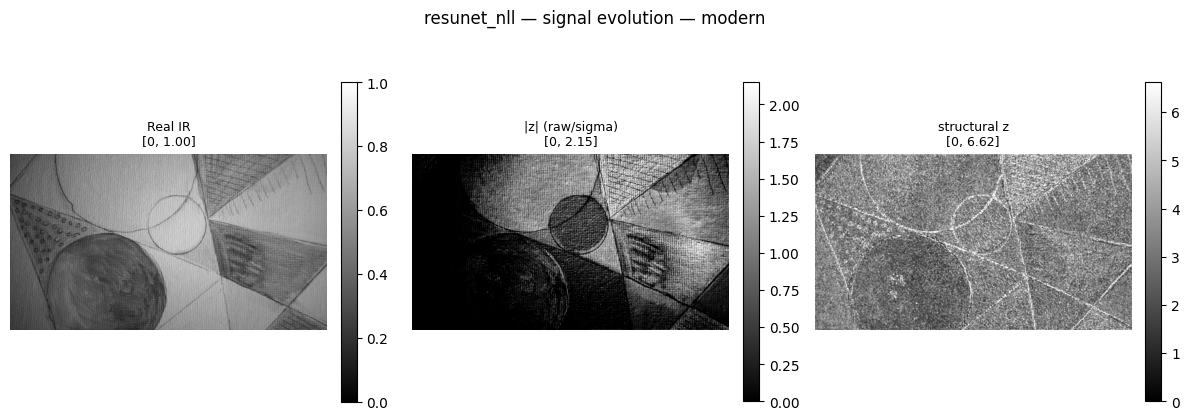

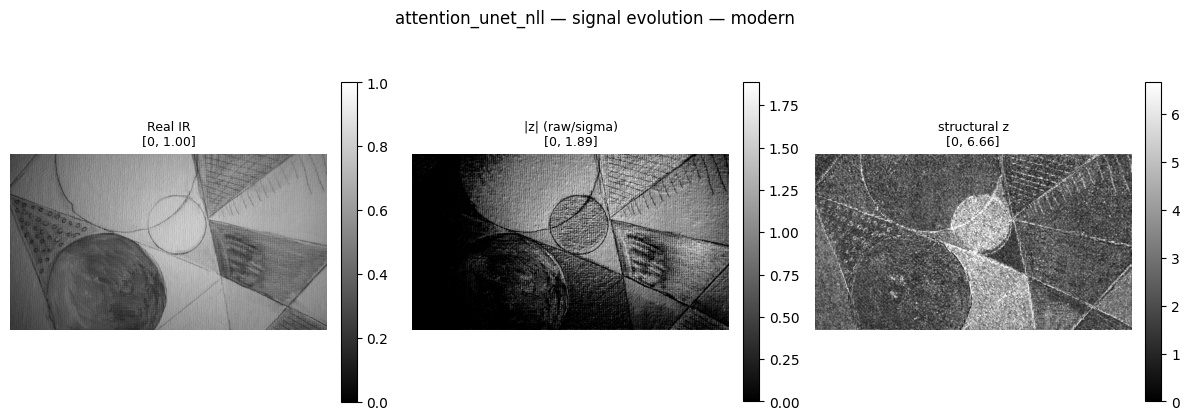


=== modern2 ===


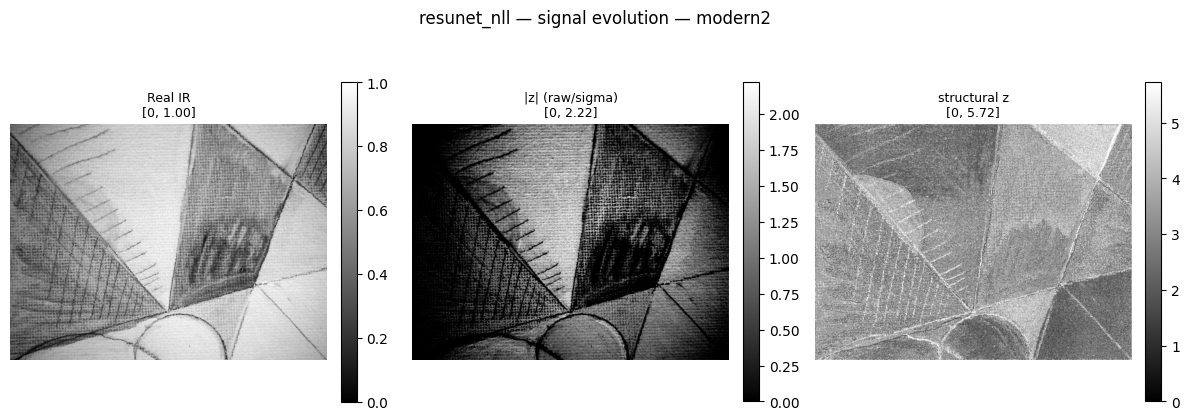

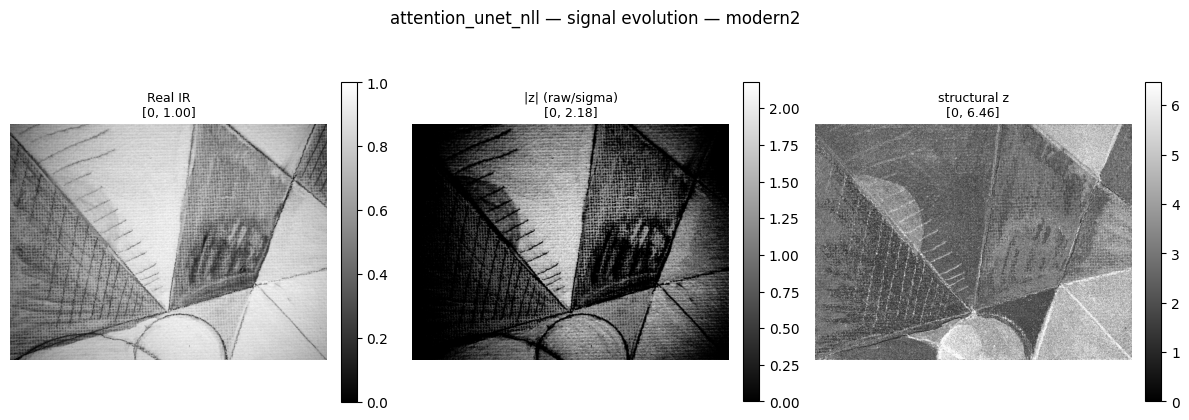


=== total ===


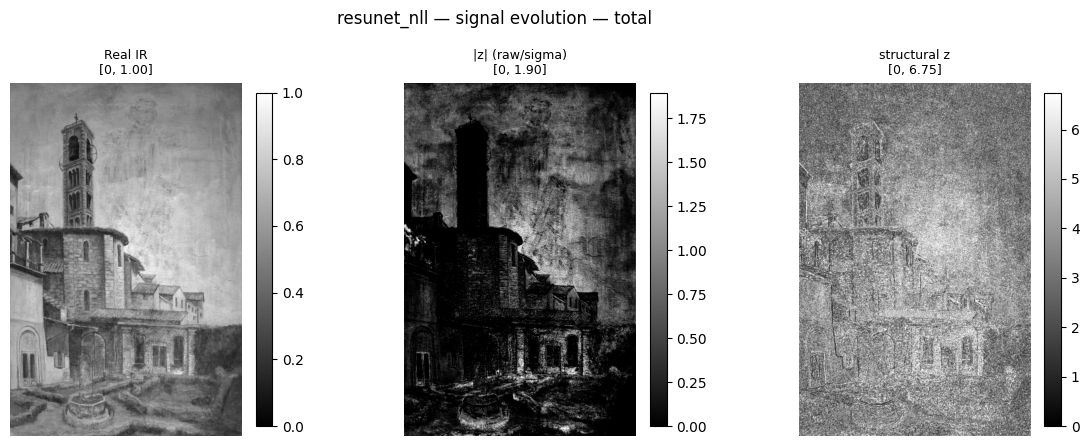

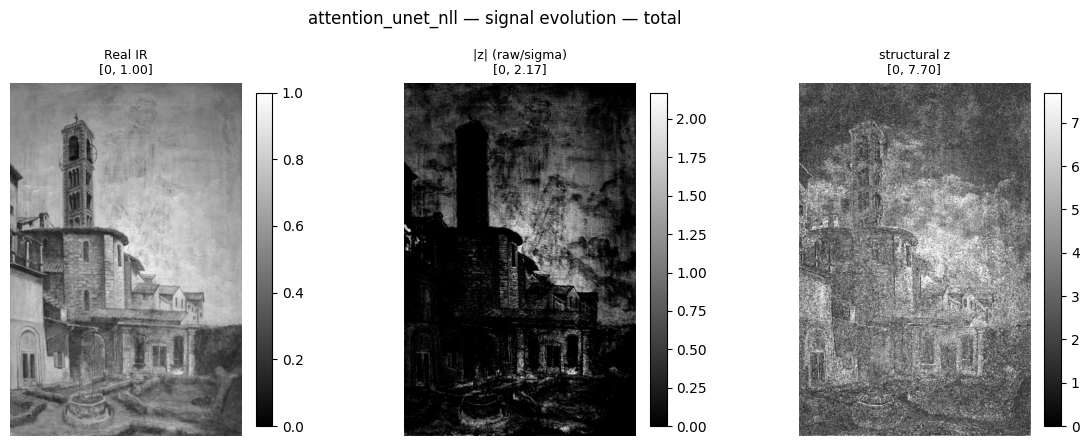

In [6]:
for rgb_path, ir_path in image_pairs:
    print(f"\n=== {rgb_path.stem} ===")
    rgb, ir = load_pair(rgb_path, ir_path)

    for name in models:
        signals = signals_for_model(name, rgb, ir)
        plot_signal_gallery(
            ir, signals, title=f"{name} — signal evolution — {rgb_path.stem}"
        )
        plt.show()